In [1]:
import os
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
from transformers import AutoConfig, AutoModelForSequenceClassification
import sys

# Import settings and architectures
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.config import MODEL_NAME, DEVICE, MAX_LEN, BATCH_SIZE, DATA_DIR, MODEL_DIR, SEEDS
from src.data_loader import tokenizer
from src.evaluation import get_preds
from src.rs_model import RationaleSupervisedRoberta
from src.mtl_model import RobertaMTL
from src.combined_model import CombinedRoberta
from src.baseline_model import RobertaBaseline 

Microsoft Visual C++ Redistributable is not installed, this may lead to the DLL load failure.
It can be downloaded at https://aka.ms/vs/17/release/vc_redist.x64.exe


In [ ]:
# LOAD DATA
df_gold = pd.read_csv(os.path.join(parent_dir, DATA_DIR, 'processed/golden_set_clean.csv'))
y_true = df_gold['label'].values
texts = df_gold['text'].tolist()

In [ ]:
all_preds = {m: [] for m in ['Baseline', 'MTL', 'RS', 'Combined']}

abs_model_dir = os.path.abspath(os.path.join(parent_dir, "models"))
for seed in SEEDS:
    print(f"\nLoading Models for Seed {seed}")
    # Baseline 
    base_path = os.path.join(abs_model_dir, f"baseline_models/baseline_seed{seed}.pt")
    config = AutoConfig.from_pretrained(MODEL_NAME)
    model = RobertaBaseline(MODEL_NAME, config).to(DEVICE)
    model.load_state_dict(torch.load(base_path, map_location=DEVICE, weights_only=True))
    all_preds['Baseline'].append(get_preds(model, texts, is_mtl=False))

    # RS 
    rs_path = os.path.join(abs_model_dir, f"rs_models/rs_seed{seed}_lam0.1.pt")
    model_rs = RationaleSupervisedRoberta(MODEL_NAME, AutoConfig.from_pretrained(MODEL_NAME)).to(DEVICE)
    model_rs.load_state_dict(torch.load(rs_path, map_location=DEVICE, weights_only=True))
    all_preds['RS'].append(get_preds(model_rs, texts, is_mtl=False))

    # MTL
    mtl_path = os.path.join(abs_model_dir, f"mtl_models/tuned_mtl_seed{seed}_lam0.2.pt")
    model_mtl = RobertaMTL(MODEL_NAME, AutoConfig.from_pretrained(MODEL_NAME)).to(DEVICE)
    model_mtl.load_state_dict(torch.load(mtl_path, map_location=DEVICE, weights_only=True))
    all_preds['MTL'].append(get_preds(model_mtl, texts, is_mtl=True))

    # Combined 
    comb_path = os.path.join(abs_model_dir, f"combined_models/comb_seed{seed}_lam0.2.pt")
    model_comb = CombinedRoberta(MODEL_NAME, AutoConfig.from_pretrained(MODEL_NAME)).to(DEVICE)
    model_comb.load_state_dict(torch.load(comb_path, map_location=DEVICE, weights_only=True))
    all_preds['Combined'].append(get_preds(model_comb, texts, is_mtl=True))

    # Cleanup memory
    del model, model_rs, model_mtl, model_comb
    torch.cuda.empty_cache()




Loading Models for Seed 7


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
classifier.out_proj.weight      | UNEXPECTED |  | 
classifier.dense.weight         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
classifier.out_proj.bias        | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
classifier.dense.bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Predicting:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# ENSEMBLE & BOOTSTRAP 
def get_ensemble(pred_list):
    # Majority voting across seeds
    stacked = np.stack(pred_list, axis=1)
    from scipy.stats import mode
    ens_vote, _ = mode(stacked, axis=1)
    return ens_vote.flatten()

ensemble_results = {m: get_ensemble(preds) for m, preds in all_preds.items() if preds}

In [5]:
def run_bootstrap_analysis(y_true, y_pred, n_iterations=10000):
    rng = np.random.default_rng(42)
    boot_scores = []
    n = len(y_true)
    for _ in range(n_iterations):
        idx = rng.integers(0, n, n)
        boot_scores.append(f1_score(y_true[idx], y_pred[idx], average='macro'))
    
    return {
        'obs': f1_score(y_true, y_pred, average='macro'),
        'low': np.percentile(boot_scores, 2.5),
        'high': np.percentile(boot_scores, 97.5),
        'scores': np.array(boot_scores)
    }

In [ ]:
# 4. PAIRWISE SIGNIFICANCE 
def get_p_value(scores_a, scores_b):
    diff = scores_a - scores_b
    p_val = np.mean(diff <= 0)
    return p_val

In [7]:
# Execute Bootstrap
stats_summary = {}
for model_name, y_pred in ensemble_results.items():
    stats_summary[model_name] = run_bootstrap_analysis(y_true, y_pred)

In [8]:
results_list = []
baseline_scores = stats_summary['Baseline']['scores']

for model_name, res in stats_summary.items():
    p_val = get_p_value(res['scores'], baseline_scores) if model_name != 'Baseline' else 1.0
    
    results_list.append({
        'Model': model_name,
        'Ensemble F1': res['obs'],
        '95% CI': f"[{res['low']:.3f}, {res['high']:.3f}]",
        'CI Width': res['high'] - res['low'],
        'p-val (vs Baseline)': p_val
    })

df_results = pd.DataFrame(results_list).sort_values('Ensemble F1', ascending=False)

In [ ]:
# Simple Holm-Bonferroni Correction
df_results = df_results.sort_values('p-val (vs Baseline)')
n_comparisons = len(df_results) - 1
df_results['Sig (Holm)'] = False

for i in range(n_comparisons):
    alpha_adj = 0.05 / (n_comparisons - i)
    if df_results.iloc[i]['p-val (vs Baseline)'] < alpha_adj:
        df_results.iloc[i, df_results.columns.get_loc('Sig (Holm)')] = True
    else:
        break

print("\n--- FINAL GOLDEN SET RESULTS ---")
print(df_results.sort_values('Ensemble F1', ascending=False))


--- FINAL GOLDEN SET RESULTS ---
      Model  Ensemble F1          95% CI  CI Width  p-val (vs Baseline)  \
3  Combined     0.721531  [0.610, 0.815]  0.204457               0.0001   
2        RS     0.694255  [0.581, 0.790]  0.208153               0.0013   
1       MTL     0.652132  [0.541, 0.750]  0.208434               0.0122   
0  Baseline     0.568960  [0.447, 0.676]  0.228951               1.0000   

   Sig (Holm)  
3        True  
2        True  
1        True  
0       False  


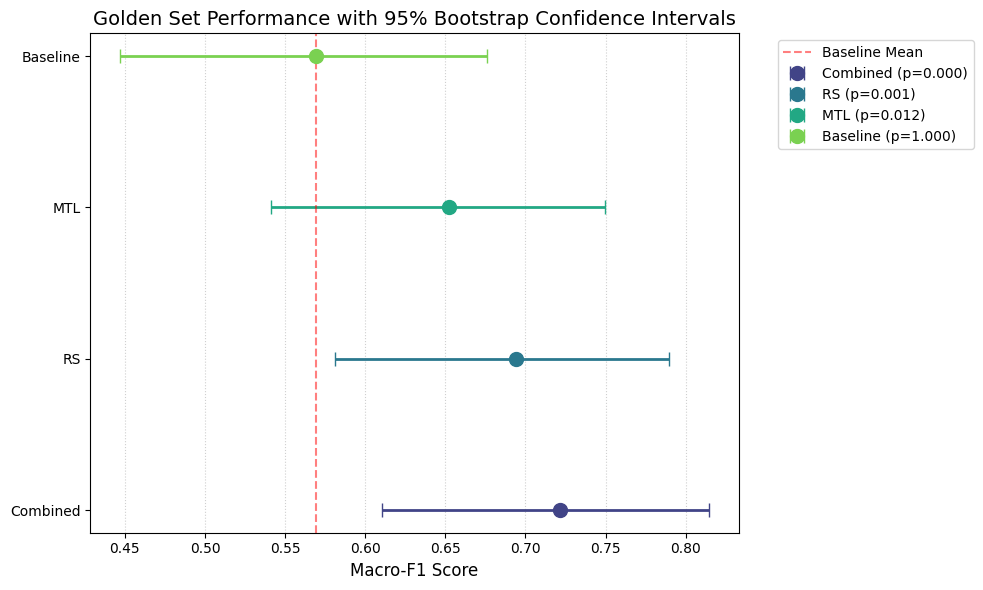

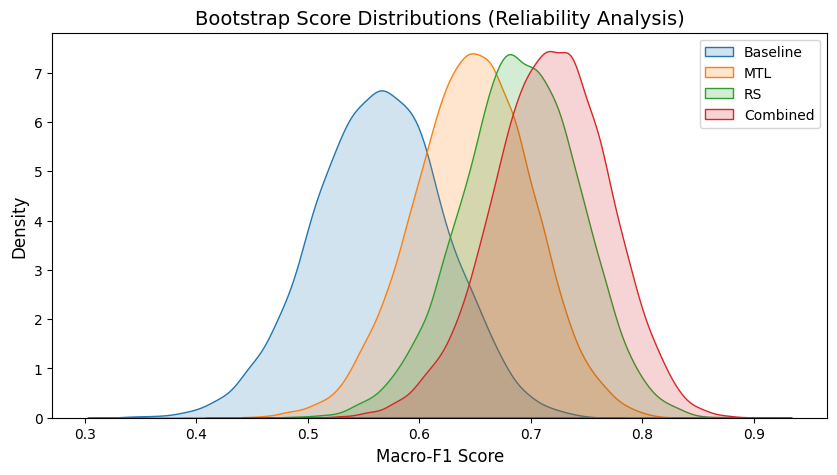

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data for Plotting
plot_df = df_results.copy()
# Convert CI to numbers for error bars
plot_df['low'] = plot_df['Model'].apply(lambda m: stats_summary[m]['low'])
plot_df['high'] = plot_df['Model'].apply(lambda m: stats_summary[m]['high'])
plot_df['err_low'] = plot_df['Ensemble F1'] - plot_df['low']
plot_df['err_high'] = plot_df['high'] - plot_df['Ensemble F1']

# Forest plot
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(plot_df))

for i, (idx, row) in enumerate(plot_df.iterrows()):
    plt.errorbar(x=row['Ensemble F1'], y=i, 
                 xerr=[[row['err_low']], [row['err_high']]], 
                 fmt='o', color=colors[i], markersize=10, capsize=5, elinewidth=2,
                 label=f"{row['Model']} (p={row['p-val (vs Baseline)']:.3f})")

plt.yticks(range(len(plot_df)), plot_df['Model'])
plt.axvline(x=df_results.loc[df_results['Model']=='Baseline', 'Ensemble F1'].values[0], 
            color='red', linestyle='--', alpha=0.5, label='Baseline Mean')

plt.title('Golden Set Performance with 95% Bootstrap Confidence Intervals', fontsize=14)
plt.xlabel('Macro-F1 Score', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Bootstrap score distributions
plt.figure(figsize=(10, 5))
for model_name, res in stats_summary.items():
    sns.kdeplot(res['scores'], label=model_name, fill=True, alpha=0.2)

plt.title('Bootstrap Score Distributions (Reliability Analysis)', fontsize=14)
plt.xlabel('Macro-F1 Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()